# HW2: Longwave Radiative Transfer and Weighting Functions
Willa Tobin

## Part I: Weighting Function

Assume a well-mixed gas with extinction coefficient $\beta_e(z) = C e^{-z/H}$, where $C$ is the gas concentration coefficient and $H$ is the scale height.

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_columns', None)

In [54]:
MU_BAR = 3/5
SIGMA = 5.670374419e-8  # W m-2 K-4
H = 8000

### 1. Optical Depths

$$\tau(0, z) = \int_0^z \beta_e(z')\,dz' = CH\left(1 - e^{-z/H}\right)$$

$$\tau(z, \infty) = \int_z^\infty \beta_e(z')\,dz' = CH\,e^{-z/H}$$

$$\tau^* = \tau(0, \infty) = CH$$

In [55]:
def beta_e(z,c):
    return c*np.exp(-z/H)

def tau_0_z(z,c):
    return c*H*(1 - np.exp(-z/H))

def tau_z_inf(z,c):
    return c*H*np.exp(-z/H)

In [56]:
def gas_conc(f):
    return f*1.25*10**-4

In [57]:
z = np.arange(0,5*H)
f = np.array([0.001,0.01,0.1,1,10,100])

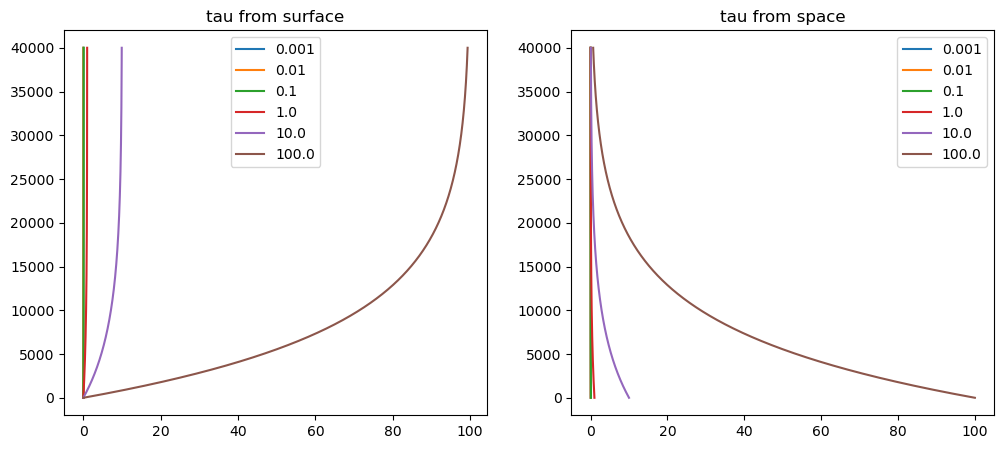

In [58]:
fig, ax = plt.subplots(1,2,figsize = (12,5))

for i in f:
    tau1 = tau_0_z(z=z,c=gas_conc(i))
    tau2 = tau_z_inf(z=z,c=gas_conc(i))

    ax[0].plot(tau1,z,label=i)
    ax[1].plot(tau2,z,label=i)

ax[0].set_title('tau from surface')
ax[1].set_title('tau from space')

ax[0].legend()
ax[1].legend()

### 2. Flux Transmittance from $z$ to TOA

$$t_F(z, \infty) = \exp\!\left(-\frac{\tau(z,\infty)}{\bar{\mu}}\right) = \exp\!\left(-\frac{CH\,e^{-z/H}}{\bar{\mu}}\right)$$

with $\bar{\mu} = 1/r = 3/5$ for diffusivity factor $r = 5/3$.

In [59]:
def t_f_z_inf(z,c):
    return np.exp(-c*H*np.exp(-z/H)/MU_BAR)

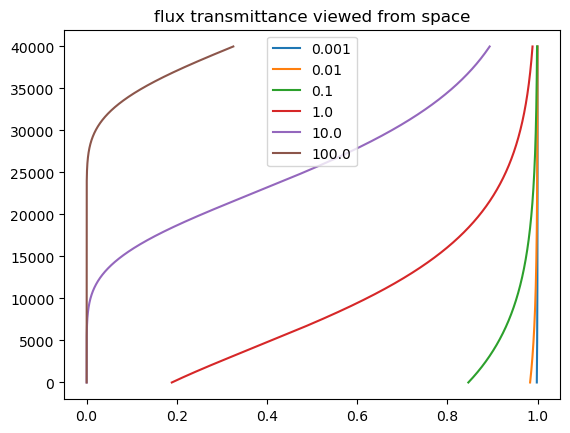

In [60]:
fig, ax = plt.subplots()

for i in f:
    t = t_f_z_inf(z=z,c=gas_conc(i))

    ax.plot(t,z,label=i)

ax.set_title('flux transmittance viewed from space')

ax.legend()


### 3. Upwelling Flux Weighting Function

$$W_F^{\uparrow}(z) = \frac{d\, t_F(z, \infty)}{dz} = \frac{C}{\bar{\mu}}\,e^{-z/H}\,t_F(z,\infty)$$

In [61]:
def w_f_up(z,c):
    return (c/MU_BAR)*np.exp(-z/H)*np.exp(-c*H*np.exp(-z/H)/MU_BAR)

def w_f_down(z,c):
    return c/MU_BAR*np.exp(-z/H)*np.exp(-c*H/MU_BAR*(1-np.exp(-z/H)))

### 4. Plot $W_F^{\uparrow}(z)$ for $f = 0.001,\, 0.01,\, 0.1,\, 1,\, 10,\, 100$

With $C = f \times 1.25 \times 10^{-4}\ \text{m}^{-1}$.

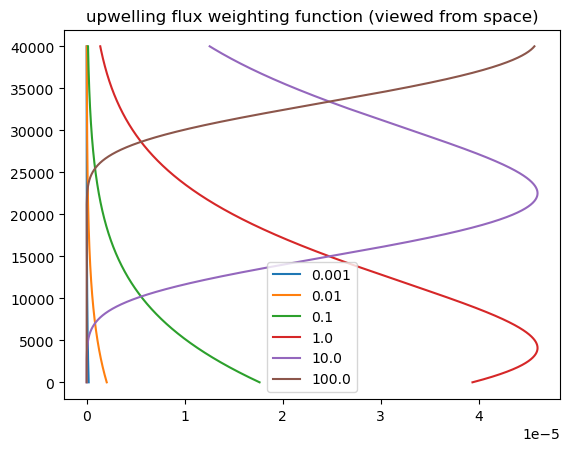

In [62]:
fig, ax = plt.subplots()

for i in f:
    x = w_f_up(z=z,c=gas_conc(i))

    ax.plot(x,z,label=i)

ax.set_title('upwelling flux weighting function (viewed from space)')

ax.legend()

### 5. Based on these results, how do changes in $f$ (and thus $C$) alter the outgoing longwave radiation?

Higher gas concentrations (values of f/C) shift the peak of the weighting function up, moving the effective emission height up to a higher place in the atmosphere. Depending on the temperature profile, this could increase or decrease the outgoing longwave radiation (increase if temperature increases with height, decrease if temperature decreases with height).

## Part II: TOA LW Radiation

### 1. Upwelling Monochromatic Flux at TOA, $F_\lambda^{\uparrow}(\infty)$

$$F_\lambda^{\uparrow}(\infty) = \pi B_\lambda(T_s)\, t_F(0, \infty) + \int_0^\infty \pi B_\lambda(T(z))\, W_F^{\uparrow}(z)\, dz$$

In [63]:
def planck_fnc(wavelength,temp):
    h = 6.626*10**-34 # planks constant [J*s]
    c = 2.998*10**8 # speed of light [m/s]
    kb = 1.381*10**-23 # boltzman constant [J/K]
    return 2*h*c**2/(wavelength**5*(np.exp(h*c/(wavelength*kb*temp))-1))

### 2. Monochromatic Net Flux at TOA, $F_{n,\lambda}(\infty)$

With $F_n = F^{\downarrow} - F^{\uparrow}$ and $F_\lambda^{\downarrow}(\infty) = 0$:

$$F_{n,\lambda}(\infty) = -F_\lambda^{\uparrow}(\infty)$$

The radiative forcing of the gas is:

$$\Delta F(\infty; f) = F_{n,\lambda}(\infty; f) - F_{n,\lambda}(\infty; f = 0)$$

In [64]:
def net_flux(wavelength, sfc_temp, temp_profile, f, z):
    c  = gas_conc(f)
    # surface emission attenuated to TOA
    pi_B_s = np.pi * planck_fnc(wavelength, sfc_temp)
    t_F_0_inf = np.exp(-c * H / MU_BAR)
    # atmospheric emission contribution to upwelling at TOA
    pi_B = np.pi * planck_fnc(wavelength, temp_profile)
    wf_up = w_f_up(z=z, c=c)
    F_up = pi_B_s * t_F_0_inf + np.trapezoid(pi_B * wf_up, z)
    # F_down at TOA is zero
    return -F_up

def radiative_forcing(wavelength, sfc_temp, temp_profile, f, z):
    Fn  = net_flux(wavelength, sfc_temp, temp_profile, f, z)
    Fn_0 = net_flux(wavelength, sfc_temp, temp_profile, 0, z)
    return Fn - Fn_0

### Calculate $\Delta F(\infty; f)$ at $\lambda = 15\ \mu\text{m}$ for 4 Atmospheric Profiles

Assumptions: diffusivity factor $r = 5/3$, surface temperature $T(0) = 300$ K, TOA at $z = 100$ km.

- **Case 1 — Isothermal:** $T(z) = T(0)$
- **Case 2 — Constant lapse rate:** $T(z) = T(0) - \Gamma z$, $\Gamma = 1$ K/km
- **Case 3 — Inversion:** $T(z) = T(0) - \Gamma z$, $\Gamma = -1$ K/km
- **Case 4 — More realistic:** piecewise profile with $\Gamma_d = 5$ K/km ($z \le 20$ km), $\Gamma_s = -2$ K/km ($20 < z \le 50$ km), and $T = 260$ K ($z > 50$ km)

In [65]:
z = np.arange(1,100000,1)
t_sfc = 300
f = np.linspace(0,100,1000)
wv = 15*10**-6
f_plot = [0.1, 1, 10, 100]

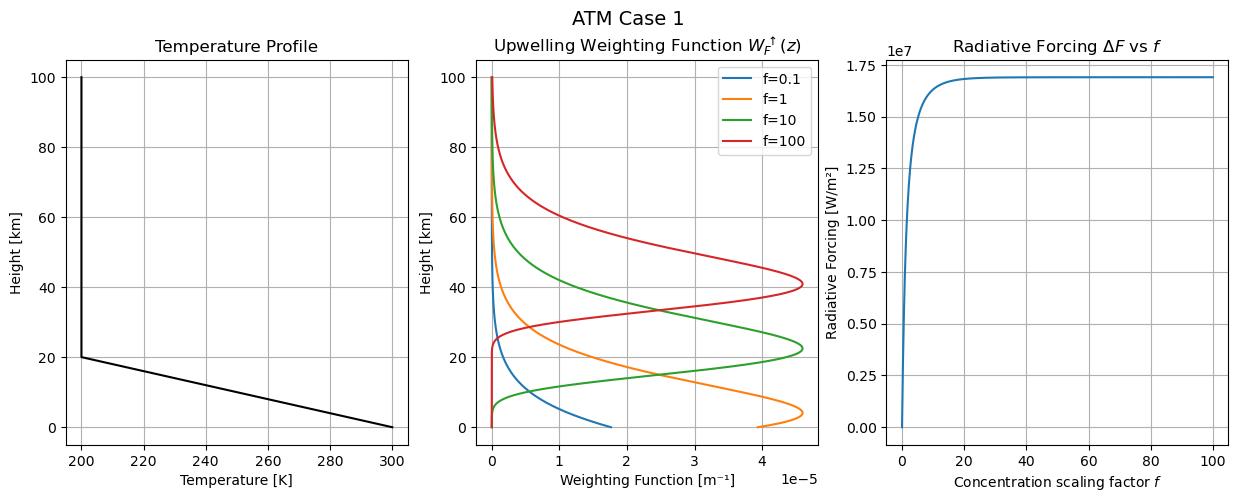

In [66]:
t_atm = t_sfc - (5 / 1000)*z
t_atm[z > 20000] = 200

df_leg_lapse = pd.DataFrame({'f':f})

# df_leg_lapse['flux_up_inf_sfc'] = df_leg_lapse.apply(lambda x: flux_up_inf_sfc(wavelength = wv, sfc_temp = t_sfc, f = x['f']), axis=1)
# df_leg_lapse['flux_up_inf_atm'] = df_leg_lapse.apply(lambda x: flux_up_inf_atm(wavelength = wv, temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_leg_lapse['net_flux'] = df_leg_lapse.apply(lambda x: net_flux(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_leg_lapse['rad_forcing'] = df_leg_lapse.apply(lambda x: radiative_forcing(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ATM Case 1', fontsize=14)

axes[0].plot(t_atm, z/1000, color='k')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Height [km]')
axes[0].set_title('Temperature Profile')
axes[0].grid(True)

for fi in f_plot:
    axes[1].plot(w_f_up(z=z, c=gas_conc(fi)), z/1000, label=f'f={fi}')
axes[1].set_xlabel('Weighting Function [m⁻¹]')
axes[1].set_ylabel('Height [km]')
axes[1].set_title('Upwelling Weighting Function $W_F^\\uparrow(z)$')
axes[1].legend()
axes[1].grid(True)

# axes[2].plot(df_isothermal['f'], df_isothermal['rad_forcing'])
df_leg_lapse.set_index('f')['rad_forcing'].plot(ax=axes[2])
axes[2].set_xlabel('Concentration scaling factor $f$')
axes[2].set_ylabel('Radiative Forcing [W/m²]')
axes[2].set_title('Radiative Forcing $\\Delta F$ vs $f$')
axes[2].grid(True)

The radiative forcing increases with larger values of f because higher gas concentrations move the peak of the weighting function up (as seen in panel 2). This means the effective emissions are coming from higher in the atmosphere, and as we can see in panel 1 that means a colder temperature. The radiative forcing is therefore positive because flux is defined as positive when traveling downwards, so the OLR is more negative for the f=0 case, and therefore the radiative forcing is positive.

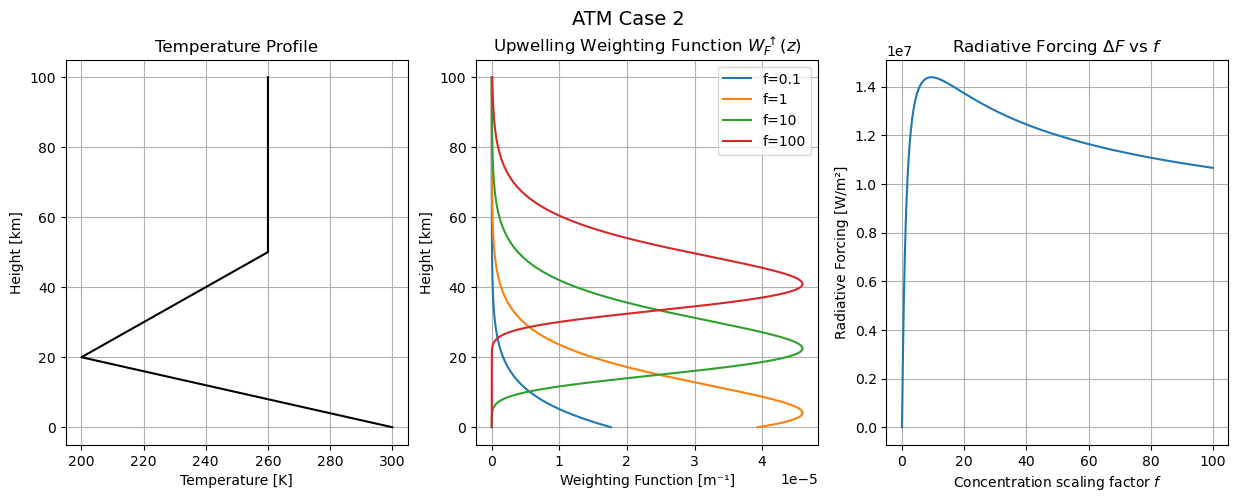

In [67]:
t_atm = t_sfc - (5 / 1000)*z
t_atm[z>20000] = 200 + (2/1000)*z[:len(z[z>20000])]
t_atm[z>50000] = 260

df_pos_lapse = pd.DataFrame({'f':f})

# df_pos_lapse['flux_up_inf_sfc'] = df_pos_lapse.apply(lambda x: flux_up_inf_sfc(wavelength = wv, sfc_temp = t_sfc, f = x['f']), axis=1)
# df_pos_lapse['flux_up_inf_atm'] = df_pos_lapse.apply(lambda x: flux_up_inf_atm(wavelength = wv, temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_pos_lapse['net_flux'] = df_pos_lapse.apply(lambda x: net_flux(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_pos_lapse['rad_forcing'] = df_pos_lapse.apply(lambda x: radiative_forcing(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('ATM Case 2', fontsize=14)

axes[0].plot(t_atm, z/1000, color='k')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Height [km]')
axes[0].set_title('Temperature Profile')
axes[0].grid(True)

for fi in f_plot:
    axes[1].plot(w_f_up(z=z, c=gas_conc(fi)), z/1000, label=f'f={fi}')
axes[1].set_xlabel('Weighting Function [m⁻¹]')
axes[1].set_ylabel('Height [km]')
axes[1].set_title('Upwelling Weighting Function $W_F^\\uparrow(z)$')
axes[1].legend()
axes[1].grid(True)

# axes[2].plot(df_isothermal['f'], df_isothermal['rad_forcing'])
df_pos_lapse.set_index('f')['rad_forcing'].plot(ax=axes[2])
axes[2].set_xlabel('Concentration scaling factor $f$')
axes[2].set_ylabel('Radiative Forcing [W/m²]')
axes[2].set_title('Radiative Forcing $\\Delta F$ vs $f$')
axes[2].grid(True)

The radiative forcing looks the same as in the last case because up to f=100, the weighting function is still peaking in the lower part of the atmosphere. As you increase f, the OLR is decreasing because the temperature is decreasing. This is why we are getting a positive radiative forcing.

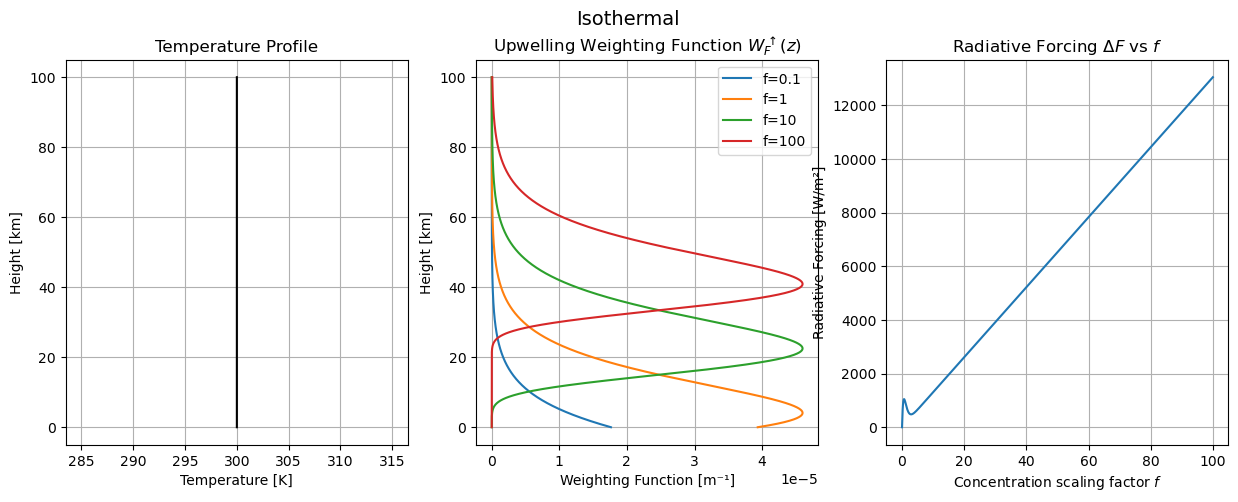

In [68]:
t_atm = np.ones(len(z))*t_sfc

df_isothermal = pd.DataFrame({'f':f})

# df_isothermal['flux_up_inf_sfc'] = df_isothermal.apply(lambda x: flux_up_inf_sfc(wavelength = wv, sfc_temp = t_sfc, f = x['f']), axis=1)
# df_isothermal['flux_up_inf_atm'] = df_isothermal.apply(lambda x: flux_up_inf_atm(wavelength = wv, temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_isothermal['net_flux'] = df_isothermal.apply(lambda x: net_flux(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)
df_isothermal['rad_forcing'] = df_isothermal.apply(lambda x: radiative_forcing(wavelength = wv, sfc_temp = t_sfc,temp_profile = t_atm, f = x['f'],z=z), axis=1)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Isothermal', fontsize=14)

axes[0].plot(t_atm, z/1000, color='k')
axes[0].set_xlabel('Temperature [K]')
axes[0].set_ylabel('Height [km]')
axes[0].set_title('Temperature Profile')
axes[0].grid(True)

for fi in f_plot:
    axes[1].plot(w_f_up(z=z, c=gas_conc(fi)), z/1000, label=f'f={fi}')
axes[1].set_xlabel('Weighting Function [m⁻¹]')
axes[1].set_ylabel('Height [km]')
axes[1].set_title('Upwelling Weighting Function $W_F^\\uparrow(z)$')
axes[1].legend()
axes[1].grid(True)

# axes[2].plot(df_isothermal['f'], df_isothermal['rad_forcing'])
df_isothermal.set_index('f')['rad_forcing'].plot(ax=axes[2])
axes[2].set_xlabel('Concentration scaling factor $f$')
axes[2].set_ylabel('Radiative Forcing [W/m²]')
axes[2].set_title('Radiative Forcing $\\Delta F$ vs $f$')
axes[2].grid(True)

For the isothermal atmosphere, the radiative forcing should be zero because no matter where you are in the atmosphere, the OLR is coming from a place with the same temperature. My model shows a positive forcing at small optical depths which is not physically correct and is likely due to numerically solving the integral or an error in my implementation.

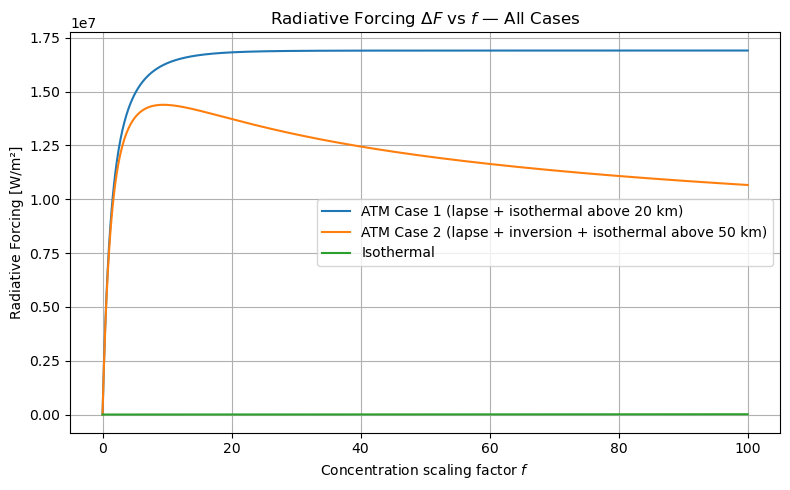

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_leg_lapse['f'], df_leg_lapse['rad_forcing'], label='ATM Case 1 (lapse + isothermal above 20 km)')
ax.plot(df_pos_lapse['f'], df_pos_lapse['rad_forcing'], label='ATM Case 2 (lapse + inversion + isothermal above 50 km)')
ax.plot(df_isothermal['f'], df_isothermal['rad_forcing'], label='Isothermal')

ax.set_xlabel('Concentration scaling factor $f$')
ax.set_ylabel('Radiative Forcing [W/m²]')
ax.set_title('Radiative Forcing $\\Delta F$ vs $f$ — All Cases')
ax.legend()
ax.grid(True)
plt.tight_layout()